# Linear Regression using Deep Neural Network
## Boston Housing Price Prediction
**Problem Statement:** Implement Boston housing price prediction by Linear Regression using Deep Neural Network. Use Boston House price prediction dataset (CSV).

In [22]:
# ── STEP 1: Import Libraries ──────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.18.0


In [24]:
# ── STEP 2: Load Dataset from CSV ────────────────────────────────
df = pd.read_csv('HousingData.csv')
df.columns = df.columns.str.strip().str.upper()

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nMissing values per column:')
print(df.isnull().sum())
df.head()

Shape: (506, 14)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Missing values per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [26]:
# ── STEP 3: Fix Missing Values (NaN) ── KEY FIX ──────────────────
# NaN values were causing the model to get stuck at loss=72
# Solution: replace each NaN with the mean of that column
df.fillna(df.mean(numeric_only=True), inplace=True)

print('Missing values AFTER fix:')
print(df.isnull().sum())   # all must be 0
print('\nMEDV stats:')
print(df['MEDV'].describe())

Missing values AFTER fix:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

MEDV stats:
count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


In [28]:
# ── STEP 4: Separate Features and Target ─────────────────────────
X = df.drop(columns=['MEDV']).values
y = df['MEDV'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('y sample:', y[:5])

X shape: (506, 13)
y shape: (506,)
y sample: [24.  21.6 34.7 33.4 36.2]


In [30]:
# ── STEP 5: Train-Test Split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (404, 13) | Test: (102, 13)


In [32]:
# ── STEP 6: Scale Features ────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Scaling done.')

Scaling done.


In [34]:
# ── STEP 7: Build Deep Neural Network ────────────────────────────
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(13,)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(1)                        # linear output — no activation
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ── STEP 8: Train ─────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

print(f'First 5 losses : {[round(x,2) for x in history.history["loss"][:5]]}')
print(f'Last  5 losses : {[round(x,2) for x in history.history["loss"][-5:]]}')
print(f'\nFinal Train MSE : {history.history["loss"][-1]:.4f}')
print(f'Final Val   MSE : {history.history["val_loss"][-1]:.4f}')

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.3681 - mae: 1.6473 - val_loss: 19.9698 - val_mae: 3.2765
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.2480 - mae: 1.6324 - val_loss: 19.9146 - val_mae: 3.2753
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1250 - mae: 1.6163 - val_loss: 19.6200 - val_mae: 3.2592
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0469 - mae: 1.6068 - val_loss: 19.6700 - val_mae: 3.2678
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.9002 - mae: 1.5844 - val_loss: 19.6372 - val_mae: 3.2633
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7658 - mae: 1.5679 - val_loss: 19.5862 - val_mae: 3.2756
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6920 - mae: 1.5602 - val_loss: 19.6005 - val_mae: 3.2735
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6003 - mae: 1.5461 - val_loss: 19.5792 - val_mae: 3.2766
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4971

In [46]:
# ── STEP 9: Evaluate on Test Set ─────────────────────────────────
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f'Test MSE  : {loss:.4f}')
print(f'Test MAE  : {mae:.4f}')
print(f'Test RMSE : {np.sqrt(loss):.4f}')

Test MSE  : 13.2084
Test MAE  : 2.3786
Test RMSE : 3.6343


In [42]:
# ── STEP 10: Predictions ──────────────────────────────────────────
predictions = model.predict(X_test, verbose=0).flatten()

print('First 10 Predictions vs Actual:')
print(f'{"Predicted ($k)":>16}  {"Actual ($k)":>12}  {"Error":>8}')
print('-' * 42)
for i in range(10):
    err = predictions[i] - y_test[i]
    print(f'  {predictions[i]:>12.1f}      {y_test[i]:>8.1f}   {err:>+7.1f}')

First 10 Predictions vs Actual:
  Predicted ($k)   Actual ($k)     Error
------------------------------------------
          26.7          23.6      +3.1
          37.0          32.4      +4.6
          13.9          13.6      +0.3
          24.2          22.8      +1.4
          14.9          16.1      -1.2
          20.6          20.0      +0.6
          17.7          17.8      -0.1
          13.4          14.0      -0.6
          23.0          19.6      +3.4
          17.7          16.8      +0.9


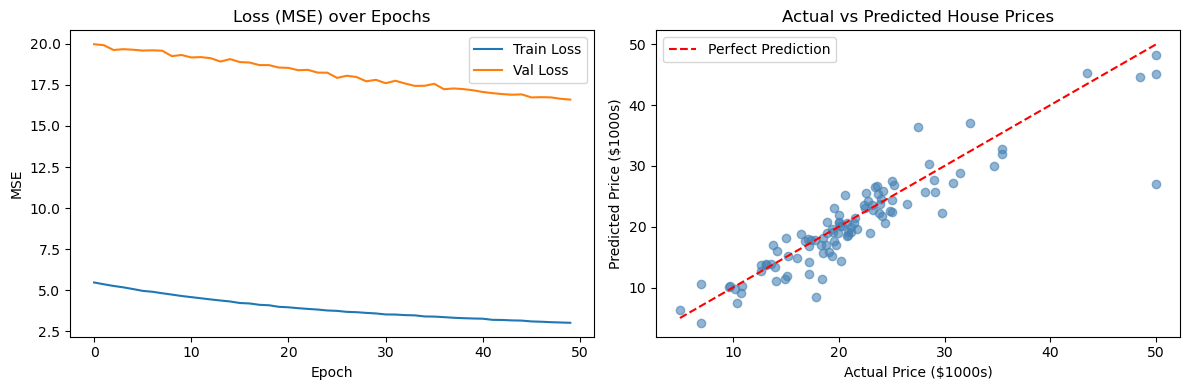

In [44]:
# ── STEP 11: Plots ────────────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Actual vs Predicted House Prices')
plt.legend()

plt.tight_layout()
plt.show()